<a href="https://colab.research.google.com/github/ariitooo/Building-a-Brain-Tumor-Detection-Using-Deep-Learning-MRI-Images-Detection-Using-Computer-Vision/blob/main/Building-a-Brain-Tumor-Detection-Using-Deep-Learning-MRI-Images-Detection-Using-Computer-Vision%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
import os
import numpy as np
import random
from PIL import Image , ImageEnhance
import matplotlib.pyplot as plt


#keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Flatten,Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import load_model
from sklearn.utils import shuffle
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,auc
import seaborn as sns
from keras.preprocessing.image import load_img,img_to_array



In [9]:
# !unzip "/content/drive/MyDrive/Colab Notebooks/archive.zip"
train_dir = "/content/Training"
test_dir ="/content/Testing"
# train_dir = "/content/drive/MyDrive/MRI images/Training"
# test_dir ="/content/drive/MyDrive/MRI images/Testing"

train_paths = []
train_labels =[]
for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir,label)):
    train_paths.append(os.path.join(train_dir,label,image))
    train_labels.append(label)

train_paths,train_labels = shuffle(train_paths,train_labels)


test_paths = []
test_labels =[]
for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir,label)):
    test_paths.append(os.path.join(test_dir,label,image))
    test_labels.append(label)

test_paths,test_labels = shuffle(test_paths,test_labels)

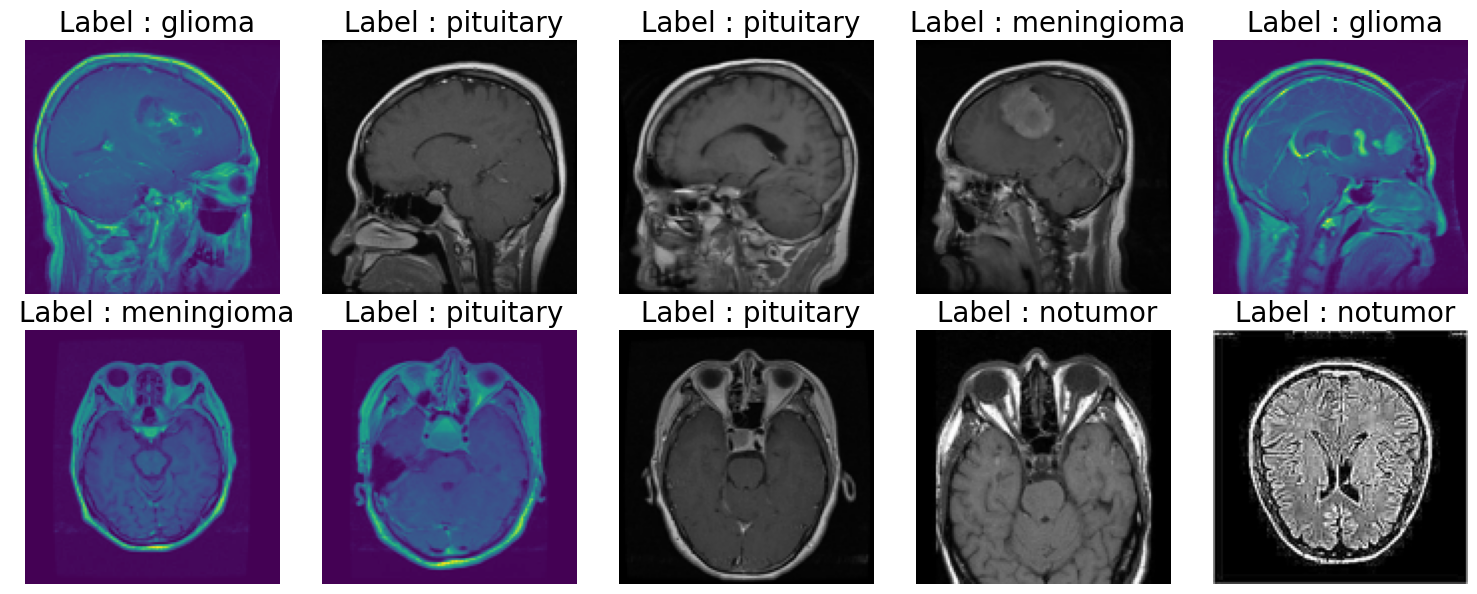

In [10]:
random_indices = random.sample(range(len(train_paths)), 10)

fig, axes =plt.subplots(2,5 ,figsize=(15,6))
axes =axes.ravel()
for i,idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128,128))
  axes[i].imshow(img)
  axes[i].axis ('off')
  axes[i].set_title(f" Label : {train_labels[idx]}" , fontsize =20)
plt.tight_layout()
plt.show()





In [11]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

In [12]:

# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - loss: 0.4918 - sparse_categorical_accuracy: 0.8120
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - loss: 0.2516 - sparse_categorical_accuracy: 0.9071
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - loss: 0.1723 - sparse_categorical_accuracy: 0.9370
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - loss: 0.1123 - sparse_categorical_accuracy: 0.9598
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - loss: 0.0977 - sparse_categorical_accuracy: 0.9650


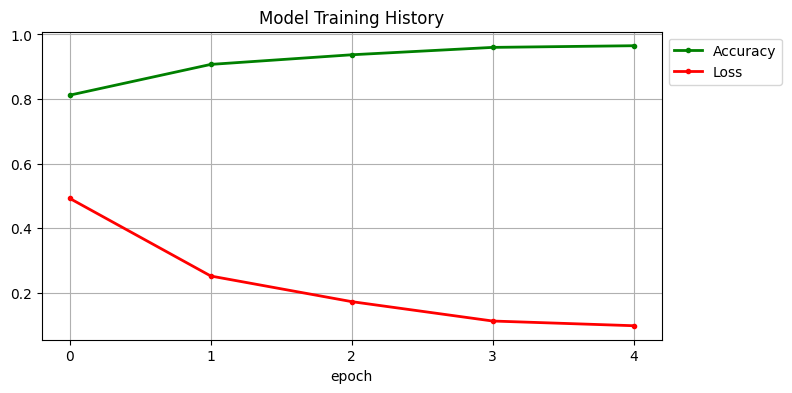

In [13]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g', linestyle ="-", linewidth=2)
plt.plot(history.history['loss'], '.r',linestyle ="-", linewidth=2)
plt.title('Model Training History')
plt.xlabel ('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy' , 'Loss'], loc='upper left', bbox_to_anchor=(1,1))
plt.show()


In [14]:
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)

print('Classification Report:')
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       400
           1       0.94      0.98      0.96       400
           2       0.84      0.91      0.87       400
           3       0.93      0.75      0.83       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



Confudion Matrics
[[399   0   0   1]
 [  1 394   5   0]
 [  2  14 364  20]
 [ 25  10  65 300]]


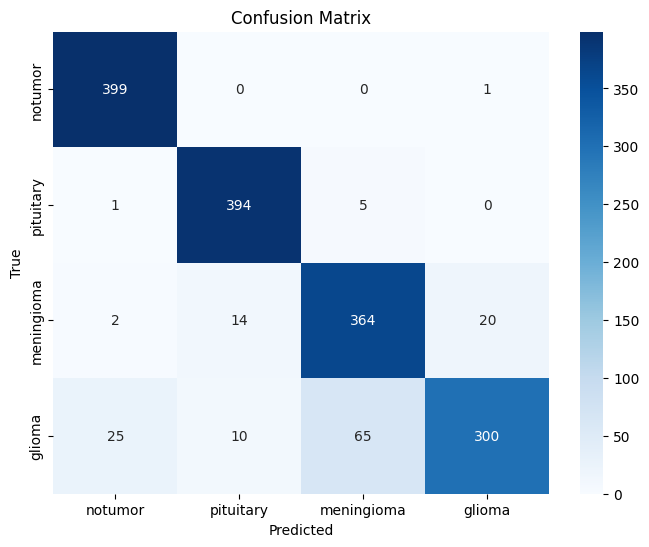

In [15]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confudion Matrics")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(test_dir))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

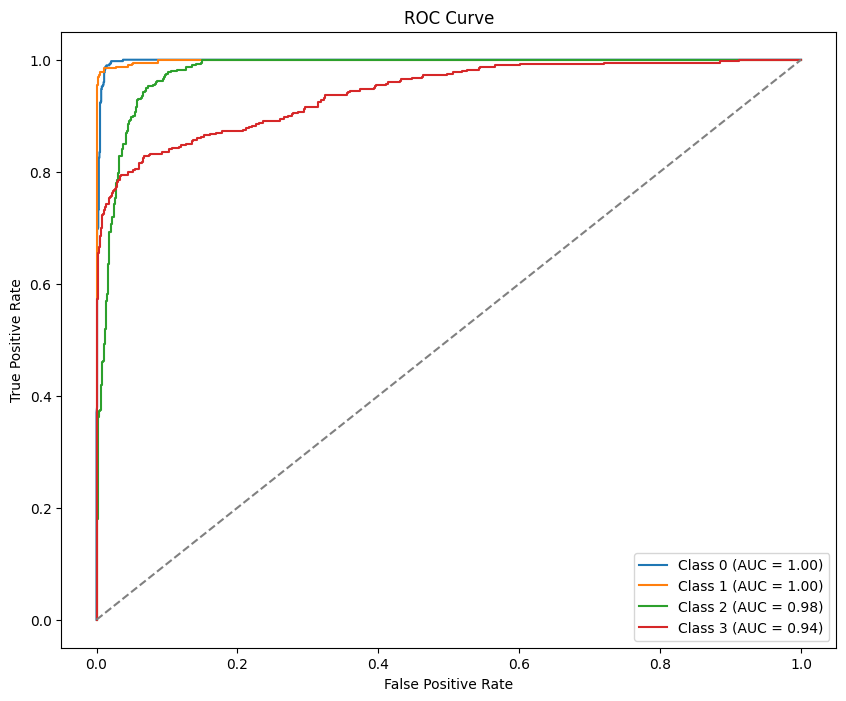

In [16]:
test_labels_bin = label_binarize(test_labels_encoded , classes = np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions


fpr,tpr,roc_auc = {} , {}, {}
for i in range(len(os.listdir(train_dir))):
  fpr[i],tpr[i],_ = roc_curve(test_labels_bin[:,i],test_predictions_bin[:,i])
  roc_auc[i] = auc(fpr[i],tpr[i])

plt.figure(figsize = (10,8))
for i in range (len(os.listdir(train_dir))):
  plt.plot(fpr[i] , tpr[i] , label = f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1],[0,1],linestyle = "--" , color = "gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()



In [17]:
model.save("model.h5")

In [18]:
model = load_model('model.h5')

In [37]:
class_labels = ['notumor','pituitary', 'meningioma' , 'glioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


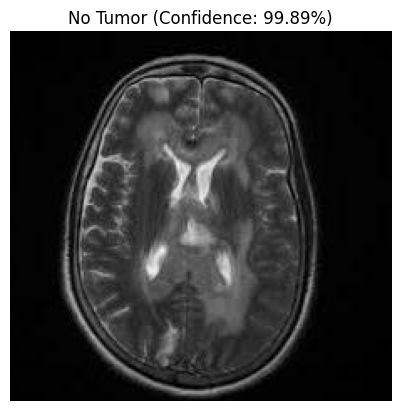

In [38]:
image_path = '/content/Testing/notumor/Te-no_155.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


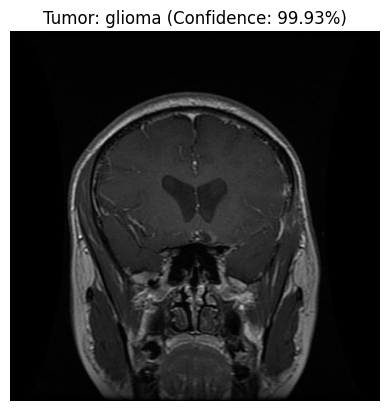

In [39]:
image_path = '/content/Testing/glioma/Te-gl_150.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


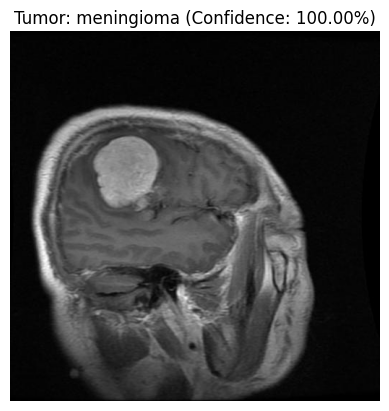

In [41]:
image_path = '/content/Testing/meningioma/Te-me_161.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


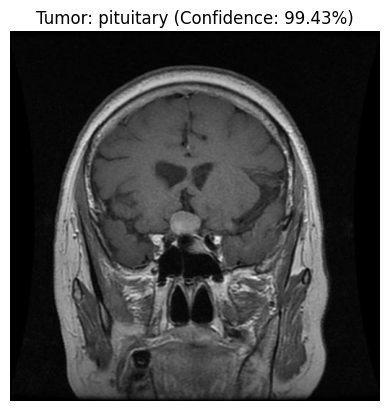

In [43]:
image_path = '/content/Testing/pituitary/Te-pi_1.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)